In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.preprocessing import StandardScaler

plt.style.use("default")

#Load the Dataset

In [9]:
train_df = pd.read_csv("../data/raw/exoTrain.csv")
test_df = pd.read_csv("../data/raw/exoTest.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (5087, 3198)
Test Shape: (570, 3198)


#Seperating Labels and Features

In [10]:
from matplotlib.pyplot import axis
X_train = train_df.drop("LABEL", axis=1)
y_train = train_df["LABEL"]

X_test = test_df.drop("LABEL", axis=1)
y_test = test_df["LABEL"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5087, 3197)
y_train: (5087,)
X_test: (570, 3197)
y_test: (570,)


In [ ]:
#Converting Labels to 0 and 1

y_train = y_train.map({1: 0, 2: 1})
y_test = y_test.map({1: 0, 2: 1})

In [13]:
X_train.describe()

,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,FLUX.10,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
count,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,...,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5087.000000,5087.000000,5087.000000,5087.000000
mean,1.445054e+02,1.285778e+02,1.471348e+02,1.561512e+02,1.561477e+02,1.469646e+02,1.168380e+02,1.144983e+02,1.228639e+02,1.410852e+02,...,3.485578e+02,4.956476e+02,6.711211e+02,7.468790e+02,6.937372e+02,6.553031e+02,-494.784966,-544.594264,-440.239100,-300.536399
std,2.150669e+04,2.179717e+04,2.191309e+04,2.223366e+04,2.308448e+04,2.410567e+04,2.414109e+04,2.290691e+04,2.102681e+04,1.942289e+04,...,2.864786e+04,3.551876e+04,4.349963e+04,4.981375e+04,5.087103e+04,5.339979e+04,17844.469520,17722.339334,16273.406292,14459.795577
min,-2.278563e+05,-3.154408e+05,-2.840018e+05,-2.340069e+05,-4.231956e+05,-5.975521e+05,-6.724046e+05,-5.790136e+05,-3.973882e+05,-2.223300e+05,...,-3.240480e+05,-3.045540e+05,-2.933140e+05,-2.838420e+05,-3.288214e+05,-5.028894e+05,-775322.000000,-732006.000000,-700992.000000,-643170.000000
25%,-4.234000e+01,-3.952000e+01,-3.850500e+01,-3.505000e+01,-3.195500e+01,-3.338000e+01,-2.813000e+01,-2.784000e+01,-2.683500e+01,-2.797500e+01,...,-1.760000e+01,-1.948500e+01,-1.757000e+01,-2.076000e+01,-2.226000e+01,-2.440500e+01,-26.760000,-24.065000,-21.135000,-19.820000
50%,-7.100000e-01,-8.900000e-01,-7.400000e-01,-4.000000e-01,-6.100000e-01,-1.030000e+00,-8.700000e-01,-6.600000e-01,-5.600000e-01,-9.600000e-01,...,2.600000e+00,2.680000e+00,3.050000e+00,3.590000e+00,3.230000e+00,3.500000e+00,-0.680000,0.360000,0.900000,1.430000
75%,4.825500e+01,4.428500e+01,4.232500e+01,3.976500e+01,3.975000e+01,3.514000e+01,3.406000e+01,3.170000e+01,3.045500e+01,2.874500e+01,...,2.211000e+01,2.235000e+01,2.639500e+01,2.909000e+01,2.780000e+01,3.085500e+01,18.175000,18.770000,19.465000,20.280000
max,1.439240e+06,1.453319e+06,1.468429e+06,1.495750e+06,1.510937e+06,1.508152e+06,1.465743e+06,1.416827e+06,1.342888e+06,1.263870e+06,...,1.779338e+06,2.379227e+06,2.992070e+06,3.434973e+06,3.481220e+06,3.616292e+06,288607.500000,215972.000000,207590.000000,211302.000000


#Largest flux value

In [14]:
row_max = X_train.max(axis=1)

print(row_max.nlargest(10))

778     4299288.00
954     2641624.75
497     1612730.00
3340    1510937.00
4493    1419728.00
4202    1242173.00
4186    1212507.00
1951     927082.00
1814     743790.50
1953     568402.88
dtype: float64


#Let's Visualize the Worst Star

<function matplotlib.pyplot.show(close=None, block=None)>

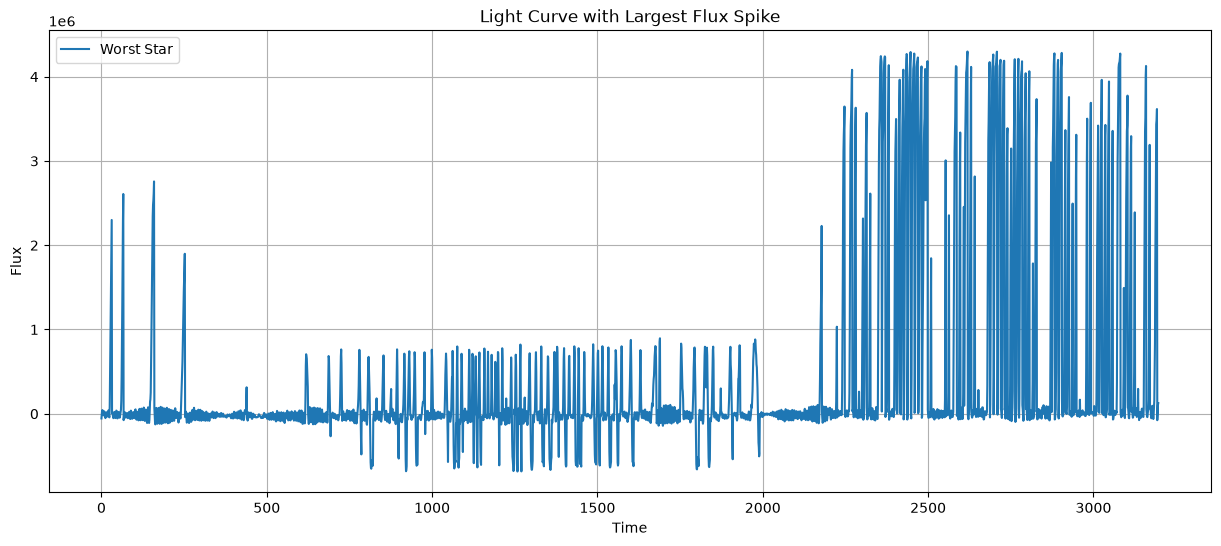

In [20]:
worst_star_idx = row_max.idxmax()

sample = X_train.iloc[worst_star_idx]

plt.figure(figsize=(15,6))
plt.plot(sample.values, label = "Worst Star")
plt.title("Light Curve with Largest Flux Spike")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.grid(True)
plt.legend()
plt.show

#Standardization

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [22]:
print("Mean: ", np.mean(X_train_scaled))
print("Std: ", np.std(X_train_scaled))

Mean:  -2.9709458937593055e-20
Std:  1.0


#Comparison of Before vs After scaling 

In [ ]:
#Let's choose the first star
sample = X_train.iloc[0]
sample_scaled = X_train_scaled[0]

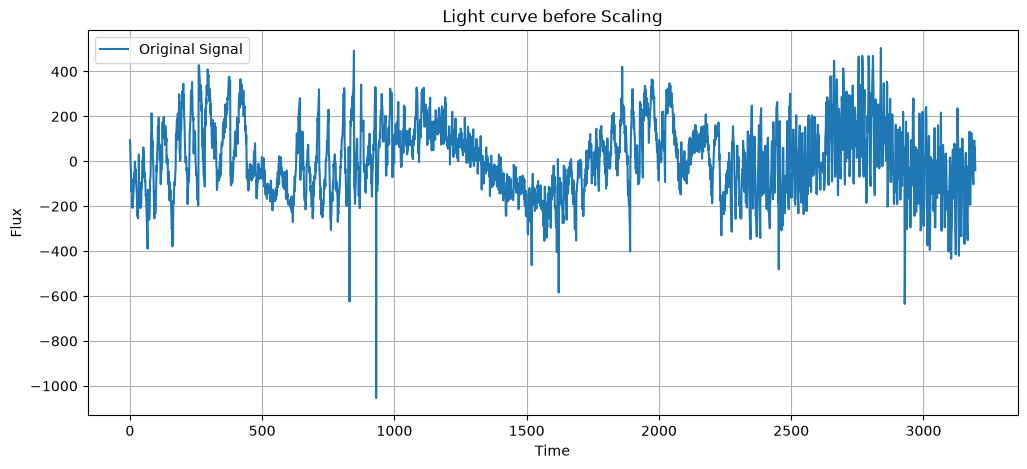

In [ ]:
#Before Scaling
plt.figure(figsize=(12,5))

plt.plot(sample.values, label="Original Signal")

plt.title("Light curve before Scaling")
plt.xlabel("Time")
plt.ylabel("Flux")

plt.grid(True)
plt.legend()
plt.show()


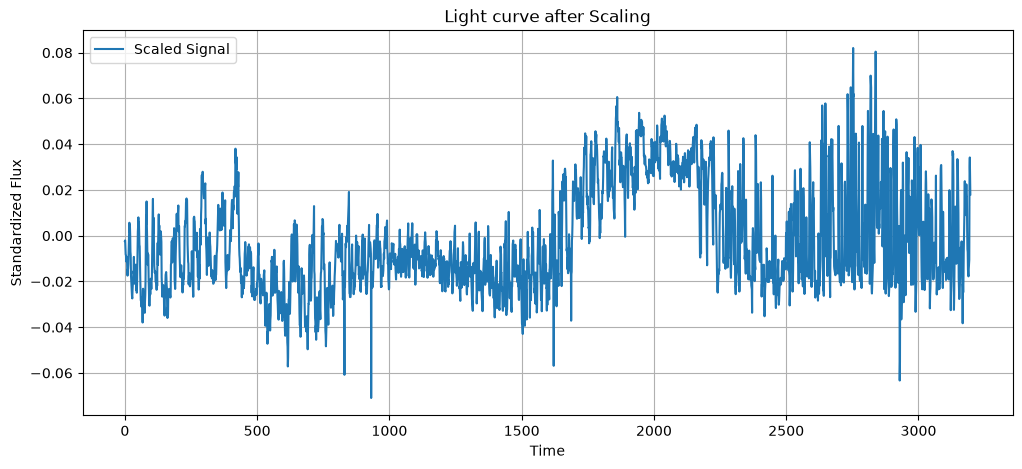

In [25]:
#After scaling

plt.figure(figsize=(12,5))

plt.plot(sample_scaled, label = "Scaled Signal")

plt.title("Light curve after Scaling")
plt.xlabel("Time")
plt.ylabel("Standardized Flux")

plt.grid(True)
plt.legend()
plt.show()

#Saving the Preprocessed Data

In [27]:
np.save("../data/processed/X_train_scaled.npy", X_train_scaled)
np.save("../data/processed/X_test_scaled.npy", X_test_scaled)

np.save("../data/processed/y_train.npy", y_train)
np.save("../data/processed/y_test.npy", y_test)

#Verify the saved files

In [28]:
X_train_loaded = np.load("../data/processed/X_train_scaled.npy")

print(X_train_scaled.shape)

(5087, 3197)
